In [21]:
%pip install yfinance pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
import yfinance as yf
import pandas as pd

In [23]:
etfs = ['XLK', 'XLF', 'XLE', 'XLV', 'XLY', 'XLI', 'XLP', 'XLU', 'XLB', 'XLRE', 'XLC']
benchmark = 'SPY'

tickers = etfs + [benchmark]
print(tickers)

['XLK', 'XLF', 'XLE', 'XLV', 'XLY', 'XLI', 'XLP', 'XLU', 'XLB', 'XLRE', 'XLC', 'SPY']


In [24]:
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")
print(data.head())
print(data.columns)

[*********************100%***********************]  12 of 12 completed

Price            Close                                                  \
Ticker             SPY        XLB XLC        XLE        XLF        XLI   
Date                                                                     
2015-01-02  170.589600  19.495245 NaN  25.714991  16.358448  46.341251   
2015-01-05  167.508850  18.998348 NaN  24.651203  16.014481  45.258778   
2015-01-06  165.931046  18.830040 NaN  24.289066  15.769731  44.701138   
2015-01-07  167.998810  19.042425 NaN  24.340807  15.935104  45.037361   
2015-01-08  170.979904  19.495245 NaN  24.887247  16.173229  45.939426   

Price                                             ... Volume            \
Ticker            XLK        XLP XLRE        XLU  ...    XLC       XLE   
Date                                              ...                    
2015-01-02  18.106760  36.067276  NaN  16.626709  ...    NaN  55498200   
2015-01-05  17.830351  35.813644  NaN  16.423431  ...    NaN  90790400   
2015-01-06  17.615374  35.768875  NaN

In [25]:
print(data.columns.get_level_values(0).unique())

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [26]:
prices = data['Close']
prices.head()

Ticker,SPY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,
2015-01-02,170.589600,19.495245,NaN,25.714991,16.358448,46.341251,18.106760,36.067276,NaN,16.626709,57.292408,31.700205
2015-01-05,167.508850,18.998348,NaN,24.651203,16.014481,45.258778,17.830351,35.813644,NaN,16.423431,57.000221,31.093903
2015-01-06,165.931046,18.830040,NaN,24.289066,15.769731,44.701138,17.615374,35.768875,NaN,16.433945,56.808212,30.784115
2015-01-07,167.998810,19.042425,NaN,24.340807,15.935104,45.037361,17.764547,36.380573,NaN,16.595169,58.143906,31.270947
2015-01-08,170.979904,19.495245,NaN,24.887247,16.173229,45.939426,18.155024,36.932587,NaN,16.710817,59.137321,31.740038


In [29]:
returns = prices.pct_change().dropna()
returns.head()

Ticker,SPY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,
2018-06-20,0.001706,-0.003249,0.012410,0.004415,-0.002560,0.000683,0.002100,0.000979,0.010794,0.000797,0.002121,0.004742
2018-06-21,-0.006269,-0.010635,-0.006129,-0.018516,-0.002932,-0.012555,-0.007684,0.001956,0.005967,0.003384,-0.005762,-0.007123
2018-06-22,0.001823,0.014563,0.004376,0.019951,-0.004780,0.003455,-0.003238,0.008202,0.008742,0.006944,0.004494,-0.001704
2018-06-25,-0.013613,-0.015551,-0.020598,-0.020093,-0.010713,-0.012670,-0.020763,0.005036,-0.002476,0.016552,-0.009184,-0.021739
2018-06-26,0.002214,0.003819,0.001658,0.012629,-0.003361,0.003766,0.004039,-0.004240,0.005275,0.001163,-0.003090,0.007162


In [30]:
volatility = returns.std()
volatility

Ticker
SPY     0.012369
XLB     0.014162
XLC     0.014554
XLE     0.021007
XLF     0.015386
XLI     0.013800
XLK     0.016661
XLP     0.010010
XLRE    0.014478
XLU     0.013434
XLV     0.011066
XLY     0.015238
dtype: float64

In [31]:
correlation = returns.corr()
correlation

Ticker,SPY,XLB,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Ticker,,,,,,,,,,,,
SPY,1.000000,0.849768,0.869372,0.610919,0.847000,0.885476,0.932370,0.737550,0.749235,0.609574,0.827623,0.900992
XLB,0.849768,1.000000,0.668615,0.673874,0.838593,0.891527,0.703566,0.669322,0.701020,0.589739,0.715456,0.741185
XLC,0.869372,0.668615,1.000000,0.439185,0.661403,0.684918,0.840628,0.569425,0.591104,0.436973,0.658240,0.815382
XLE,0.610919,0.673874,0.439185,1.000000,0.711003,0.694797,0.438914,0.422123,0.461890,0.385568,0.479827,0.477609
XLF,0.847000,0.838593,0.661403,0.711003,1.000000,0.887795,0.670135,0.650983,0.681016,0.565098,0.696476,0.724703
XLI,0.885476,0.891527,0.684918,0.694797,0.887795,1.000000,0.732416,0.685593,0.719327,0.600815,0.734567,0.774154
XLK,0.932370,0.703566,0.840628,0.438914,0.670135,0.732416,1.000000,0.591319,0.608595,0.449498,0.708006,0.848018
XLP,0.737550,0.669322,0.569425,0.422123,0.650983,0.685593,0.591319,1.000000,0.710913,0.746637,0.753291,0.589137
XLRE,0.749235,0.701020,0.591104,0.461890,0.681016,0.719327,0.608595,0.710913,1.000000,0.766679,0.696409,0.652448


In [33]:
spy_corr = correlation['SPY'].drop('SPY')
spy_corr.sort_values(ascending=False)

Ticker
XLK     0.932370
XLY     0.900992
XLI     0.885476
XLC     0.869372
XLB     0.849768
XLF     0.847000
XLV     0.827623
XLRE    0.749235
XLP     0.737550
XLE     0.610919
XLU     0.609574
Name: SPY, dtype: float64

In [35]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 25.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 36.6 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


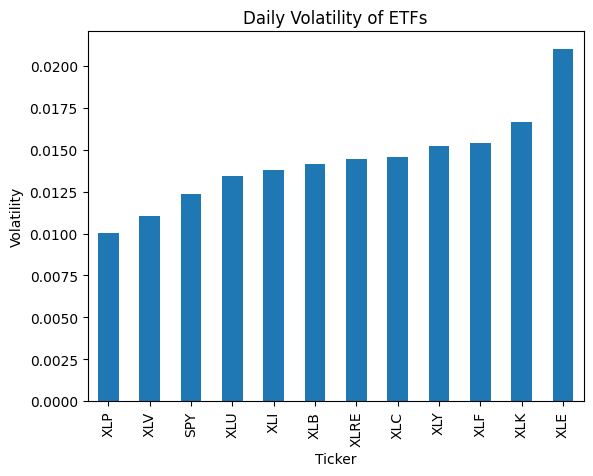

In [37]:
import matplotlib.pyplot as plt

volatility.sort_values().plot(kind='bar')
plt.title('Daily Volatility of ETFs')
plt.ylabel('Volatility')
plt.show()

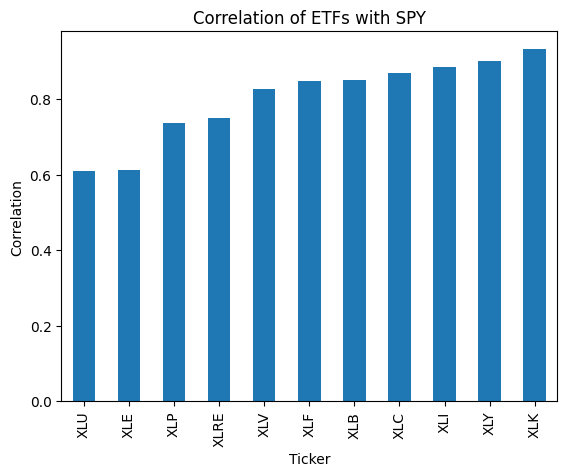

In [38]:
spy_corr.sort_values().plot(kind='bar')
plt.title('Correlation of ETFs with SPY')
plt.ylabel('Correlation')
plt.show()